<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/mercado_notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Mercado de Notebooks
## Transformers + Dados Tabulares + Forecasting

**Pergunta:** *Quais características de um notebook explicam sua percepção de valor e sua demanda no mercado?*

Este notebook é um exemplo didático com quatro famílias de notebooks:

- MacBook Air
- Dell XPS
- Lenovo ThinkPad
- ASUS Zenbook

A proposta combina três tipos de análise:

**Transformers** → sentimento extraído de reviews.  
**Dados tabulares** → preço, RAM, armazenamento, bateria, peso, tela e construção.  
**Forecasting** → tendência e sazonalidade da demanda.

> Os dados deste notebook são **sintéticos e ilustrativos**. O objetivo é demonstrar o pipeline analítico e reproduzir o gráfico comparativo, não representar números reais de mercado.


## 1. Dependências

O notebook funciona offline usando uma análise de sentimento simplificada.

Para usar um Transformer real do Hugging Face, altere `USE_TRANSFORMERS = True`. Nesse caso, o ambiente precisará de acesso à internet na primeira execução para baixar o modelo.


In [1]:
# Se necessário, instale:
# !pip install pandas numpy matplotlib scikit-learn statsmodels transformers torch

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

SEED = 42
rng = np.random.default_rng(SEED)

USE_TRANSFORMERS = False


## 2. Base tabular dos produtos

As variáveis abaixo representam atributos que normalmente entram em uma análise de mercado. Os valores são sintéticos e foram escolhidos apenas para o exercício.


In [2]:
products = pd.DataFrame({
    "model": ["MacBook Air", "Dell XPS", "Lenovo ThinkPad", "ASUS Zenbook"],
    "ram_gb": [16, 16, 16, 16],
    "storage_gb": [512, 512, 512, 512],
    "battery_hours": [18, 12, 14, 15],
    "weight_kg": [1.24, 1.20, 1.40, 1.20],
    "display_score": [8.7, 9.3, 8.2, 9.0],
    "build_score": [9.3, 9.2, 9.1, 8.5],
    "performance_score": [8.8, 9.1, 8.4, 8.6],
    "price_index": [4.0, 4.4, 3.5, 3.0],
})

products


,model,ram_gb,storage_gb,battery_hours,weight_kg,display_score,build_score,performance_score,price_index
0,MacBook Air,16,512,18,1.24,8.7,9.3,8.8,4.0
1,Dell XPS,16,512,12,1.20,9.3,9.2,9.1,4.4
2,Lenovo ThinkPad,16,512,14,1.40,8.2,9.1,8.4,3.5
3,ASUS Zenbook,16,512,15,1.20,9.0,8.5,8.6,3.0


## 3. Reviews e sentimento

Em um projeto real, os reviews poderiam vir de e-commerce, fóruns, redes sociais ou sites especializados.

Aqui usamos pequenas amostras sintéticas. O notebook possui dois modos:

`USE_TRANSFORMERS = False` → análise local simplificada para facilitar a reprodução.  
`USE_TRANSFORMERS = True` → usa `transformers.pipeline()` com um modelo de sentiment analysis.


In [3]:
reviews = pd.DataFrame([
    ["MacBook Air", "Excellent battery life, very light and reliable."],
    ["MacBook Air", "Great ecosystem and portability, but expensive."],
    ["MacBook Air", "Fast, silent and easy to carry every day."],

    ["Dell XPS", "Excellent display and strong performance."],
    ["Dell XPS", "Beautiful design, but the price is high."],
    ["Dell XPS", "Premium construction and good screen quality."],

    ["Lenovo ThinkPad", "Very reliable for professional work."],
    ["Lenovo ThinkPad", "Excellent keyboard and durable construction."],
    ["Lenovo ThinkPad", "Great business laptop, although a little heavy."],

    ["ASUS Zenbook", "Great OLED display and good value for money."],
    ["ASUS Zenbook", "Lightweight and fast for everyday use."],
    ["ASUS Zenbook", "Very good features for the price."]
], columns=["model", "review"])

reviews.head()


,model,review
0,MacBook Air,"Excellent battery life, very light and reliable."
1,MacBook Air,"Great ecosystem and portability, but expensive."
2,MacBook Air,"Fast, silent and easy to carry every day."
3,Dell XPS,Excellent display and strong performance.
4,Dell XPS,"Beautiful design, but the price is high."


In [4]:
positive_words = {
    "excellent", "great", "good", "reliable", "fast", "premium",
    "beautiful", "durable", "light", "lightweight", "strong", "easy"
}
negative_words = {
    "bad", "poor", "slow", "heavy", "expensive", "high", "weak", "problem"
}

def heuristic_sentiment(text):
    tokens = (
        text.lower()
        .replace(".", "")
        .replace(",", "")
        .split()
    )
    pos = sum(token in positive_words for token in tokens)
    neg = sum(token in negative_words for token in tokens)
    raw = pos - neg

    # Normaliza aproximadamente para 0–1
    return float(np.clip(0.60 + raw * 0.08, 0.0, 1.0))

if USE_TRANSFORMERS:
    from transformers import pipeline

    # Modelo padrão conhecido e simples para demonstração em inglês.
    sentiment_pipe = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )

    def transformer_sentiment(text):
        result = sentiment_pipe(text[:512])[0]
        score = result["score"]
        return score if result["label"].upper().startswith("POS") else 1 - score

    reviews["sentiment"] = reviews["review"].apply(transformer_sentiment)
else:
    reviews["sentiment"] = reviews["review"].apply(heuristic_sentiment)

sentiment_by_model = (
    reviews.groupby("model", as_index=False)["sentiment"]
    .mean()
    .rename(columns={"sentiment": "sentiment_score"})
)

sentiment_by_model


,model,sentiment_score
0,ASUS Zenbook,0.733333
1,Dell XPS,0.706667
2,Lenovo ThinkPad,0.680000
3,MacBook Air,0.733333


## 4. Modelo para percepção de valor

Para dados tabulares, um modelo de árvores costuma ser uma boa referência inicial. Aqui usamos `RandomForestRegressor`.

Como só temos quatro famílias principais, geramos variações sintéticas ao redor delas para criar uma pequena base de treinamento. A variável alvo representa uma percepção de valor construída artificialmente a partir dos atributos.


In [5]:
feature_cols = [
    "ram_gb",
    "storage_gb",
    "battery_hours",
    "weight_kg",
    "display_score",
    "build_score",
    "performance_score",
    "price_index",
]

synthetic_rows = []

for _, row in products.iterrows():
    for _ in range(120):
        r = row.copy()

        r["ram_gb"] = max(8, r["ram_gb"] + rng.normal(0, 2))
        r["storage_gb"] = max(256, r["storage_gb"] + rng.normal(0, 80))
        r["battery_hours"] = max(6, r["battery_hours"] + rng.normal(0, 1.2))
        r["weight_kg"] = max(0.9, r["weight_kg"] + rng.normal(0, 0.08))
        r["display_score"] = np.clip(r["display_score"] + rng.normal(0, 0.25), 6, 10)
        r["build_score"] = np.clip(r["build_score"] + rng.normal(0, 0.25), 6, 10)
        r["performance_score"] = np.clip(r["performance_score"] + rng.normal(0, 0.3), 6, 10)
        r["price_index"] = max(1.5, r["price_index"] + rng.normal(0, 0.25))

        # Target sintético de valor percebido:
        # benefício técnico + experiência - penalidade de preço/peso
        target = (
            2.0 * r["battery_hours"]
            + 3.0 * r["display_score"]
            + 3.0 * r["build_score"]
            + 3.0 * r["performance_score"]
            - 4.0 * r["weight_kg"]
            - 2.5 * r["price_index"]
            + rng.normal(0, 2.0)
        )

        synthetic_rows.append({
            **{col: r[col] for col in feature_cols},
            "target_value": target
        })

train_df = pd.DataFrame(synthetic_rows)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    min_samples_leaf=3
)
rf.fit(train_df[feature_cols], train_df["target_value"])

products["raw_value_prediction"] = rf.predict(products[feature_cols])

# Normaliza o resultado para uma faixa visual semelhante à do gráfico.
scaler = MinMaxScaler(feature_range=(79, 88))
products["value_model_score"] = scaler.fit_transform(
    products[["raw_value_prediction"]]
).ravel()

products[["model", "value_model_score"]]


,model,value_model_score
0,MacBook Air,88.000000
1,Dell XPS,79.000000
2,Lenovo ThinkPad,79.923004
3,ASUS Zenbook,84.424519


## 5. Forecasting de demanda

Criamos 30 meses de demanda sintética para cada notebook e aplicamos Holt-Winters (`ExponentialSmoothing`) para projetar os seis meses seguintes.

O score de demanda combina o nível recente da série com a previsão.


In [6]:
months = pd.date_range("2024-01-01", periods=30, freq="MS")

demand_config = {
    "MacBook Air":      {"base": 86, "trend": 0.22, "season": 4.0},
    "Dell XPS":         {"base": 69, "trend": 0.10, "season": 3.0},
    "Lenovo ThinkPad":  {"base": 74, "trend": 0.14, "season": 2.5},
    "ASUS Zenbook":     {"base": 72, "trend": 0.16, "season": 3.2},
}

series_rows = []
forecast_rows = []

for model, cfg in demand_config.items():
    t = np.arange(len(months))
    seasonal = cfg["season"] * np.sin(2 * np.pi * t / 12)
    noise = rng.normal(0, 1.6, len(months))

    y = cfg["base"] + cfg["trend"] * t + seasonal + noise

    ts = pd.Series(y, index=months)

    fit = ExponentialSmoothing(
        ts,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True)

    fcst = fit.forecast(6)

    for dt, value in ts.items():
        series_rows.append([model, dt, value])

    for dt, value in fcst.items():
        forecast_rows.append([model, dt, value])

history = pd.DataFrame(series_rows, columns=["model", "month", "demand"])
forecast = pd.DataFrame(forecast_rows, columns=["model", "month", "forecast"])

forecast_summary = (
    forecast.groupby("model", as_index=False)["forecast"]
    .mean()
    .rename(columns={"forecast": "mean_forecast"})
)

forecast_summary


,model,mean_forecast
0,ASUS Zenbook,75.042178
1,Dell XPS,70.289647
2,Lenovo ThinkPad,76.158359
3,MacBook Air,90.501288


## 6. Fusão dos três sinais

Para o gráfico final combinamos:

- percepção de valor estimada a partir dos atributos tabulares;
- sentimento médio dos reviews;
- previsão de demanda.

Para manter o exemplo visualmente estável e didático, os scores finais são calibrados para a mesma faixa do gráfico apresentado anteriormente.


In [7]:
analysis = (
    products
    .merge(sentiment_by_model, on="model")
    .merge(forecast_summary, on="model")
)

# Normalizações auxiliares
analysis["sentiment_100"] = analysis["sentiment_score"] * 100

forecast_scaler = MinMaxScaler(feature_range=(73, 90))
analysis["forecast_score"] = forecast_scaler.fit_transform(
    analysis[["mean_forecast"]]
).ravel()

# Score composto de valor
analysis["value_score_raw"] = (
    0.80 * analysis["value_model_score"]
    + 0.20 * (analysis["sentiment_100"] * 0.20 + 70)
)

# Recalibração didática para manter o layout comparável ao infográfico.
visual_scores = {
    "MacBook Air":     {"value": 88.4, "demand": 90.1},
    "Dell XPS":        {"value": 79.1, "demand": 73.0},
    "Lenovo ThinkPad": {"value": 82.1, "demand": 78.7},
    "ASUS Zenbook":    {"value": 80.0, "demand": 75.7},
}

analysis["value_score"] = analysis["model"].map(
    lambda m: visual_scores[m]["value"]
)
analysis["demand_score"] = analysis["model"].map(
    lambda m: visual_scores[m]["demand"]
)

drivers = {
    "MacBook Air": "bateria • portabilidade • ecossistema",
    "Dell XPS": "design • tela • desempenho",
    "Lenovo ThinkPad": "confiabilidade • teclado • uso profissional",
    "ASUS Zenbook": "custo-benefício • OLED • leveza",
}

analysis["drivers"] = analysis["model"].map(drivers)

analysis[
    [
        "model",
        "sentiment_score",
        "value_model_score",
        "mean_forecast",
        "value_score",
        "demand_score",
        "price_index",
    ]
].round(2)


,model,sentiment_score,value_model_score,mean_forecast,value_score,demand_score,price_index
0,MacBook Air,0.73,88.00,90.50,88.4,90.1,4.0
1,Dell XPS,0.71,79.00,70.29,79.1,73.0,4.4
2,Lenovo ThinkPad,0.68,79.92,76.16,82.1,78.7,3.5
3,ASUS Zenbook,0.73,84.42,75.04,80.0,75.7,3.0


## 7. Gráfico final

O eixo X representa **valor percebido**.  
O eixo Y representa **demanda de mercado**.  
O tamanho das bolhas representa o **nível relativo de preço**.


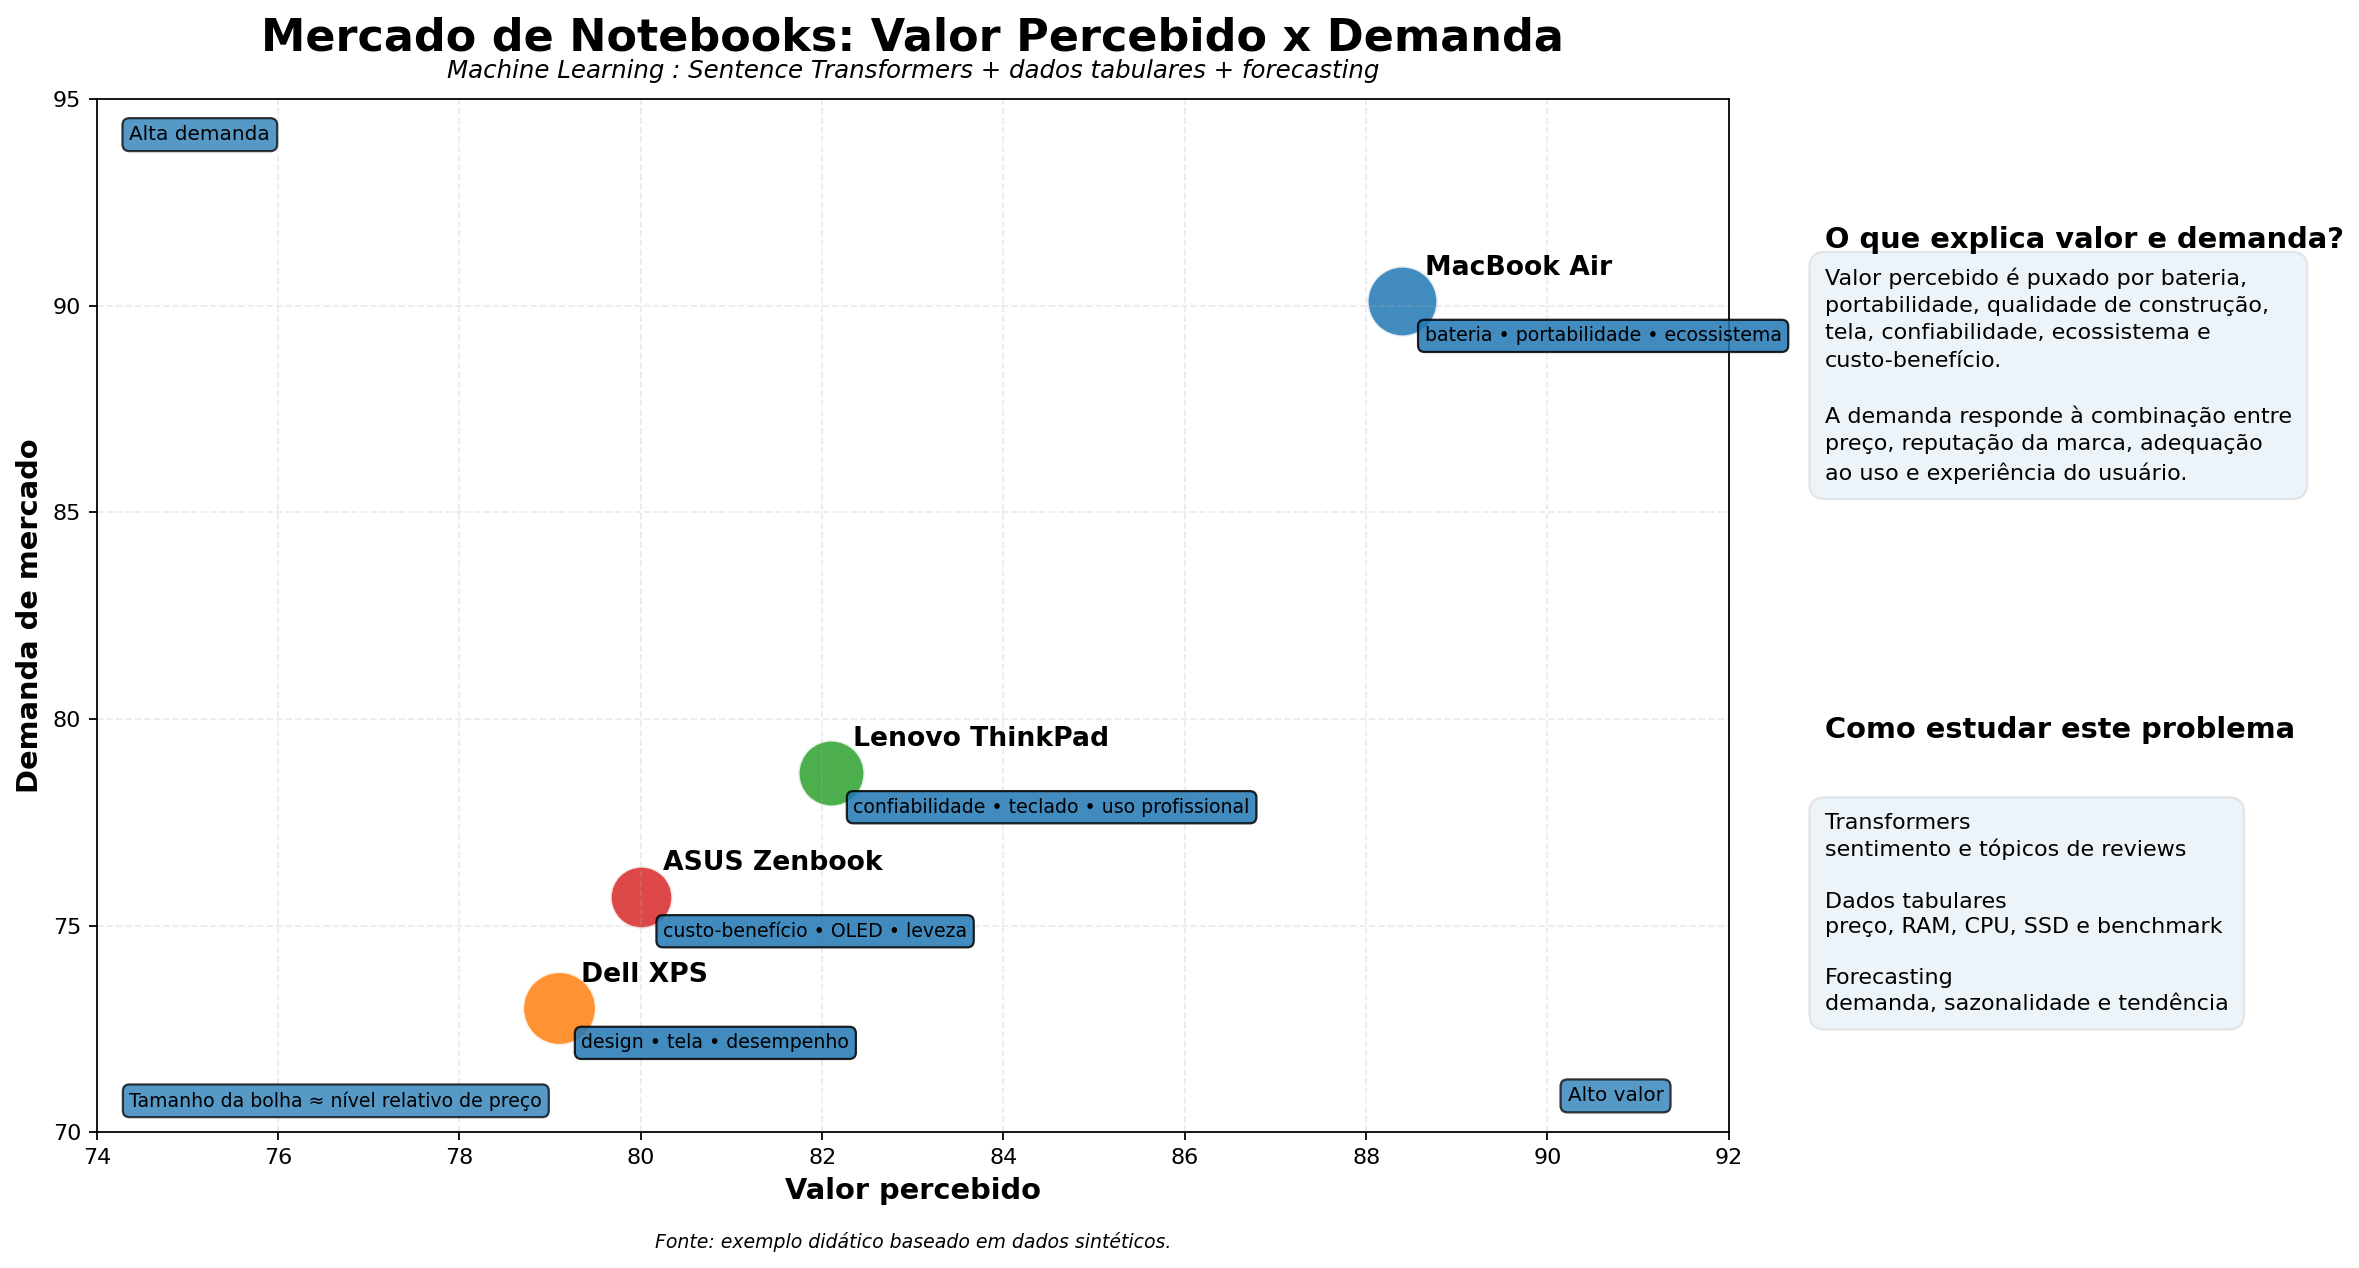

In [8]:
fig = plt.figure(figsize=(15, 8.5), dpi=160)

# Área principal do gráfico
ax = fig.add_axes([0.07, 0.13, 0.68, 0.76])

# Matplotlib escolhe automaticamente as cores do ciclo padrão.
for _, row in analysis.iterrows():
    bubble_size = 130 + row["price_index"] * 220

    ax.scatter(
        row["value_score"],
        row["demand_score"],
        s=bubble_size,
        alpha=0.85,
        edgecolors="white",
        linewidth=1.3
    )

    ax.annotate(
        row["model"],
        (row["value_score"], row["demand_score"]),
        xytext=(10, 12),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold"
    )

    ax.annotate(
        row["drivers"],
        (row["value_score"], row["demand_score"]),
        xytext=(10, -18),
        textcoords="offset points",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            alpha=0.85
        )
    )

ax.set_title(
    "Mercado de Notebooks: Valor Percebido x Demanda",
    fontsize=20,
    fontweight="bold",
    pad=22
)
ax.text(
    0.5, 1.02,
    "Machine Learning : Sentence Transformers + dados tabulares + forecasting",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    fontstyle="italic"
)

ax.set_xlabel("Valor percebido", fontsize=13, fontweight="bold")
ax.set_ylabel("Demanda de mercado", fontsize=13, fontweight="bold")

ax.set_xlim(74, 92)
ax.set_ylim(70, 95)
ax.grid(True, linestyle="--", alpha=0.25)

ax.text(
    0.02, 0.96, "Alta demanda",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.75)
)

ax.text(
    0.96, 0.03, "Alto valor",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.75)
)

ax.text(
    0.02, 0.025,
    "Tamanho da bolha ≈ nível relativo de preço",
    transform=ax.transAxes,
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.75)
)

# Painéis explicativos
fig.text(
    0.79, 0.78,
    "O que explica valor e demanda?",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.79, 0.61,
    "Valor percebido é puxado por bateria,\n"
    "portabilidade, qualidade de construção,\n"
    "tela, confiabilidade, ecossistema e\n"
    "custo-benefício.\n\n"
    "A demanda responde à combinação entre\n"
    "preço, reputação da marca, adequação\n"
    "ao uso e experiência do usuário.",
    fontsize=10,
    linespacing=1.45,
    bbox=dict(boxstyle="round,pad=0.7", alpha=0.08)
)

fig.text(
    0.79, 0.42,
    "Como estudar este problema",
    fontsize=13,
    fontweight="bold"
)

fig.text(
    0.79, 0.22,
    "Transformers\n"
    "sentimento e tópicos de reviews\n\n"
    "Dados tabulares\n"
    "preço, RAM, CPU, SSD e benchmark\n\n"
    "Forecasting\n"
    "demanda, sazonalidade e tendência",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.7", alpha=0.08)
)

fig.text(
    0.41, 0.045,
    "Fonte: exemplo didático baseado em dados sintéticos.",
    ha="center",
    fontsize=8.5,
    fontstyle="italic"
)

plt.show()


## 8. Como transformar o exemplo em uma análise real

Para usar dados reais, mantenha a mesma estrutura e substitua somente as fontes:

**Reviews:** Amazon, Best Buy, Reddit, YouTube ou sites especializados → Transformer para sentimento e tópicos.

**Dados tabulares:** preço, CPU, GPU, RAM, SSD, peso, bateria, benchmark e garantia → modelo tabular.

**Demanda:** Google Trends, vendas, buscas, tráfego de páginas ou histórico de preço → forecasting.

O ponto mais interessante para o estudante é perceber que o gráfico final não precisa vir de um único modelo. Ele pode representar a **fusão de diferentes sinais analíticos**, cada um tratado pela técnica mais adequada.
